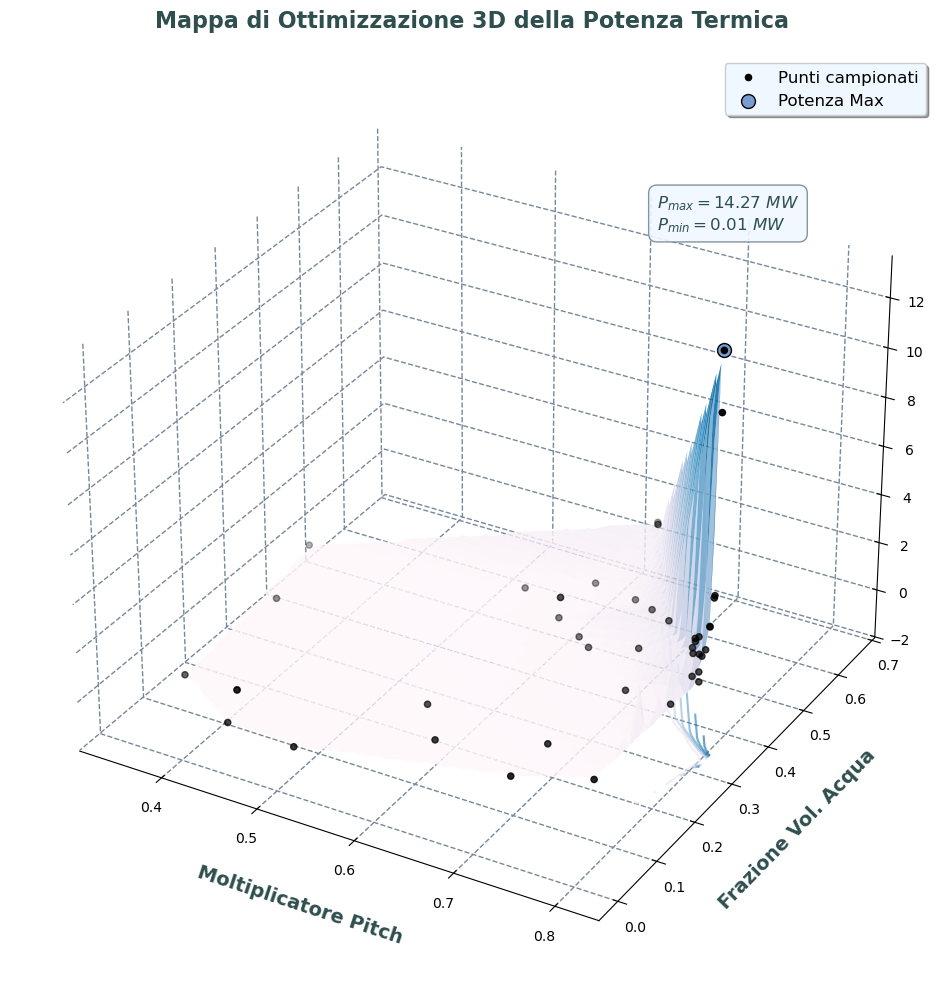

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import os

# 1. PARAMETRI FISICI
S = 2.02e17
E_f_joule = 200.0 * 1e6 * 1.6022e-19

# 2. LETTURA DATI
FILE_IN = 'result_fixed.txt'

pitches = []
mixes = []
fissions = []

if os.path.exists(FILE_IN):
    with open(FILE_IN, 'r') as f:
        for line in f:
            parts = line.split()
            if len(parts) >= 3 and parts[0].replace('.', '', 1).isdigit():
                pitches.append(float(parts[0]))
                mixes.append(float(parts[1]))
                fissions.append(float(parts[2]))

pitches = np.array(pitches)
mixes = np.array(mixes)
fissions = np.array(fissions)

# 3. CALCOLO POTENZA TERMICA [MW]
tasso_fissione = fissions * S
potenza_termica_MW = (tasso_fissione * E_f_joule) / 1e6

# 4. CREAZIONE GRIGLIA PER SURFACE PLOT (Interpolazione Lineare)
xi = np.linspace(pitches.min(), pitches.max(), 100)
yi = np.linspace(mixes.min(), mixes.max(), 100)
XI, YI = np.meshgrid(xi, yi)

# Interpolazione lineare per sopprimere le oscillazioni (undershoot non fisici)
ZI = griddata((pitches, mixes), potenza_termica_MW, (XI, YI), method='linear')

# 5. PLOTTING 3D
fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection='3d')

# Superficie 3D con colormap dai toni freddi
surf = ax.plot_surface(XI, YI, ZI, cmap='PuBu', alpha=0.85, edgecolor='none', antialiased=True)

# Proiezioni sul piano di base 
z_min = np.nanmin(ZI)
offset_val = z_min - (np.nanmax(ZI) - np.nanmin(ZI)) * 0.15
ax.contour(XI, YI, ZI, zdir='z', offset=offset_val, cmap='PuBu', alpha=0.6, linewidths=1.5)
ax.set_zlim(offset_val, np.nanmax(ZI))

# Identificazione Punti Notevoli
idx_max = np.argmax(potenza_termica_MW)
idx_min = np.argmin(potenza_termica_MW)

# Scatter Punti Campionati e Punti Notevoli
ax.scatter(pitches, mixes, potenza_termica_MW, c='#000000', s=20, label='Punti campionati', zorder=4)
ax.scatter(pitches[idx_max], mixes[idx_max], potenza_termica_MW[idx_max], 
           color='#789DD1', s=100, edgecolor='#000000', label='Potenza Max', zorder=5)

# Formattazione Assi e Titolo
ax.set_title('Mappa di Ottimizzazione 3D della Potenza Termica', fontsize=16, fontweight='bold', color='#2F4F4F', pad=20)
ax.set_xlabel('Moltiplicatore Pitch', fontsize=14, fontweight='bold', color='#2F4F4F', labelpad=15)
ax.set_ylabel('Frazione Vol. Acqua', fontsize=14, fontweight='bold', color='#2F4F4F', labelpad=15)
ax.set_zlabel('Potenza Termica [MW]', fontsize=14, fontweight='bold', color='#2F4F4F', labelpad=15)

# Stile Griglie 
grid_params = {"color": "#778899", "linestyle": "--", "linewidth": 1, "alpha": 0.6}
ax.xaxis._axinfo["grid"].update(grid_params)
ax.yaxis._axinfo["grid"].update(grid_params)
ax.zaxis._axinfo["grid"].update(grid_params)

# Rimozione del colore di sfondo dai pannelli degli assi
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

# Box Testo Dati Analitici
testo_dati = '\n'.join((
    r'$P_{max} = %.2f \ MW$' % (potenza_termica_MW[idx_max], ),
    r'$P_{min} = %.2f \ MW$' % (potenza_termica_MW[idx_min], )
))
props_box = dict(boxstyle='round,pad=0.5', facecolor='#F0F8FF', alpha=0.9, edgecolor='#778899')
ax.text2D(0.70, 0.85, testo_dati, transform=ax.transAxes, fontsize=12,
          verticalalignment='top', bbox=props_box, color='#2F4F4F')

# Legenda
ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

plt.tight_layout()
plt.show()